In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/Loan_default.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.tail()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255346,ZTH91CGL0B,62,22418,18481,636,113,2,6.73,12,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


In [ ]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
df = df.drop('LoanID' , axis = 1)

In [ ]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes: float64

In [ ]:
df['Education'].unique()

array(["Bachelor's", "Master's", 'High School', 'PhD'], dtype=object)

In [ ]:
education_encoder = pd.get_dummies(df['Education'] , prefix ='Education').astype(int)

In [ ]:
education_encoder

,Education_Bachelor's,Education_High School,Education_Master's,Education_PhD
0,1,0,0,0
1,0,0,1,0
2,0,0,1,0
3,0,1,0,0
4,1,0,0,0
...,...,...,...,...
255342,1,0,0,0
255343,0,1,0,0
255344,0,1,0,0
255345,0,1,0,0


In [ ]:
df = pd.concat([df , education_encoder], axis= 1)

In [ ]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default', 'Education_Bachelor's',
       'Education_High School', 'Education_Master's', 'Education_PhD'],
      dtype='object')

In [ ]:
EmploymentType_encoder = pd.get_dummies(df['EmploymentType'], prefix='EmploymentType', drop_first=True).astype(int)

In [ ]:
df = pd.concat([df, EmploymentType_encoder], axis=1)

In [ ]:
df.shape

(255347, 24)

In [ ]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default', 'Education_Bachelor's',
       'Education_High School', 'Education_Master's', 'Education_PhD',
       'EmploymentType_Part-time', 'EmploymentType_Self-employed',
       'EmploymentType_Unemployed'],
      dtype='object')

In [ ]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,LoanPurpose,HasCoSigner,Default,Education_Bachelor's,Education_High School,Education_Master's,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,...,Other,Yes,0,1,0,0,0,0,0,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,...,Other,Yes,0,0,0,1,0,0,0,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,...,Auto,No,1,0,0,1,0,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,...,Business,No,0,0,1,0,0,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,...,Auto,No,0,1,0,0,0,0,0,1


In [ ]:
df.loc[0]

,0
Age,56
Income,85994
LoanAmount,50587
CreditScore,520
MonthsEmployed,80
NumCreditLines,4
InterestRate,15.23
LoanTerm,36
DTIRatio,0.44
Education,Bachelor's


In [ ]:
df.drop(['Education' ,'EmploymentType'], axis = 1, inplace = True)

In [ ]:
df.loc[0]

,0
Age,56
Income,85994
LoanAmount,50587
CreditScore,520
MonthsEmployed,80
NumCreditLines,4
InterestRate,15.23
LoanTerm,36
DTIRatio,0.44
MaritalStatus,Divorced


In [ ]:
yes_no_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [ ]:
marital_encoded = pd.get_dummies(df['MaritalStatus'], prefix='Marital', drop_first=True).astype(int)
loan_purpose_encoded = pd.get_dummies(df['LoanPurpose'], prefix='Purpose', drop_first=True).astype(int)

df = pd.concat([df, marital_encoded, loan_purpose_encoded], axis=1)

In [ ]:
df.drop(['MaritalStatus', 'LoanPurpose'], axis=1, inplace=True)

In [ ]:
df.loc[0]

,0
Age,56.00
Income,85994.00
LoanAmount,50587.00
CreditScore,520.00
MonthsEmployed,80.00
NumCreditLines,4.00
InterestRate,15.23
LoanTerm,36.00
DTIRatio,0.44
HasMortgage,1.00


In [ ]:
df['Default'].value_counts()

,count
Default,
0,225694
1,29653


In [ ]:
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
y = df['Default']
X = df.drop('Default', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier()
}


In [ ]:
best_model = None
best_model_name = ""
best_auc = 0

for name, model in models.items():

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(name)
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC-AUC:", auc)
    print("-" * 40)

    if auc > best_auc:
        best_auc = auc
        best_model = model
        best_model_name = name


Logistic Regression
Accuracy: 0.6765615821421578
F1 Score: 0.33432739582493753
ROC-AUC: 0.7531787880198108
----------------------------------------
Random Forest
Accuracy: 0.8849226551791658
F1 Score: 0.035767022149302705
ROC-AUC: 0.7442275430990511
----------------------------------------
Gradient Boosting
Accuracy: 0.8863129038574505
F1 Score: 0.09309590752889722
ROC-AUC: 0.7576402426616742
----------------------------------------


In [ ]:
import joblib

best_model = GradientBoostingClassifier()
best_model.fit(X_train, y_train)

joblib.dump(best_model, 'best_loan_model.pkl')


['best_loan_model.pkl']

In [ ]:
results = []

trained_models = {}

for name, model in models.items():

    print("\nTraining:", name)

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        y_prob = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(
            X_test
        )[:, 1]

    trained_models[name] = model

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "F1 Score",
        ascending=False
    )
)


Training: Logistic Regression

Training: Random Forest

Training: Gradient Boosting


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.676562,0.219668,0.699376,0.334327,0.753179,0.310542
2,Gradient Boosting,0.886313,0.632696,0.050244,0.093096,0.757640,0.329039
1,Random Forest,0.884923,0.664634,0.018378,0.035767,0.744228,0.303653


In [ ]:
results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
)

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [ ]:
if best_model_name == "Logistic Regression":

    best_prob = best_model.predict_proba(
        X_test_scaled
    )[:, 1]

else:

    best_prob = best_model.predict_proba(
        X_test
    )[:, 1]

best_pred = (
    best_prob >= 0.50
).astype(int)

In [ ]:
print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            best_pred
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            best_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            best_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            best_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            best_prob
        ),
        4
    )
)

print(
    "PR-AUC   :",
    round(
        average_precision_score(
            y_test,
            best_prob
        ),
        4
    )
)

FINAL MODEL PERFORMANCE
Accuracy : 0.6766
Precision: 0.2197
Recall   : 0.6994
F1 Score : 0.3343
ROC-AUC  : 0.7532
PR-AUC   : 0.3105


In [ ]:
print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            best_pred
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            best_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            best_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            best_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            best_prob
        ),
        4
    )
)

print(
    "PR-AUC   :",
    round(
        average_precision_score(
            y_test,
            best_prob
        ),
        4
    )
)

FINAL MODEL PERFORMANCE
Accuracy : 0.6766
Precision: 0.2197
Recall   : 0.6994
F1 Score : 0.3343
ROC-AUC  : 0.7532
PR-AUC   : 0.3105


In [ ]:
print(
    classification_report(
        y_test,
        best_pred,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)

              precision    recall  f1-score   support

  No Default       0.94      0.67      0.79     45139
     Default       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



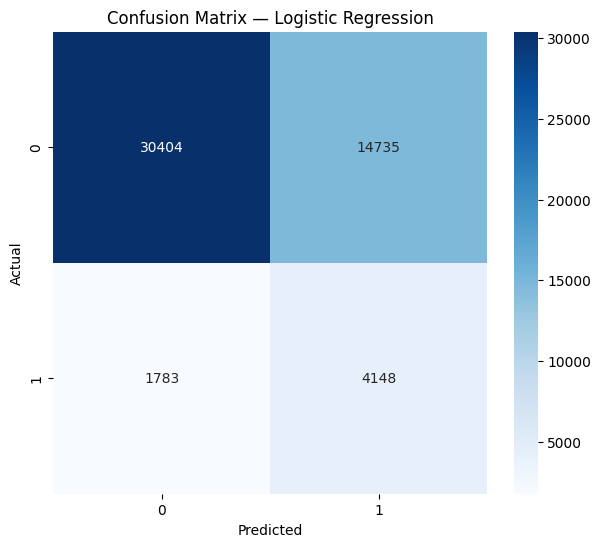

In [ ]:
cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.show()

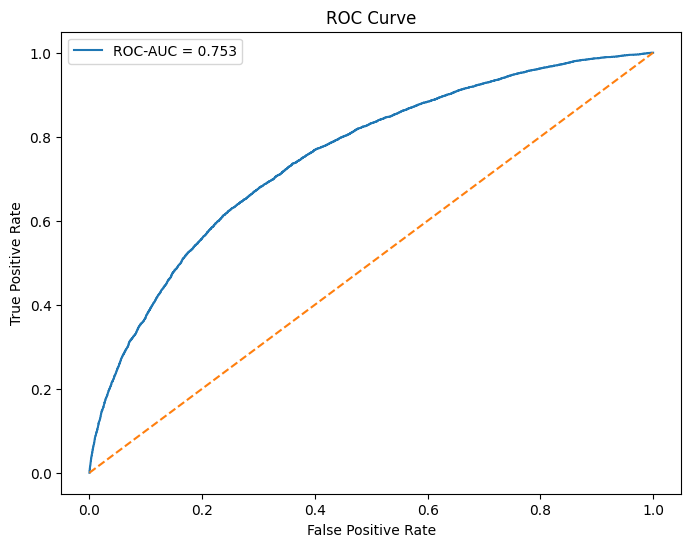

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc_score(y_test, best_prob):.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

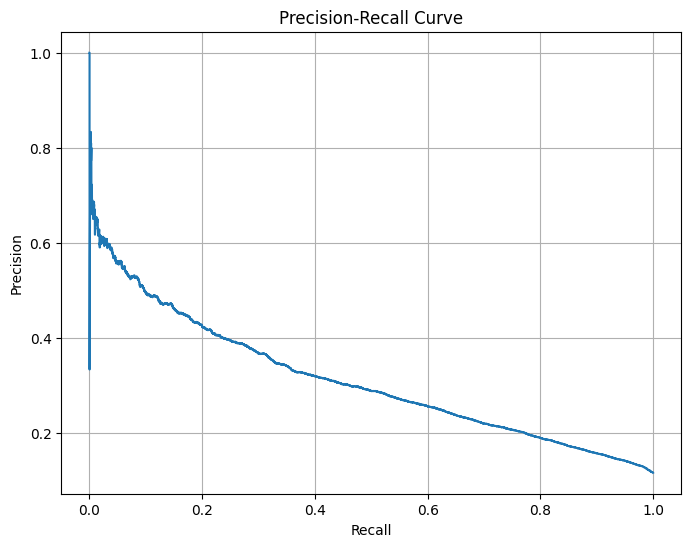

In [ ]:
precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [ ]:
threshold_values = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []

for threshold in threshold_values:

    pred = (
        best_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            pred
        ),

        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(
    "Best threshold:",
    round(
        best_threshold_row["Threshold"],
        2
    )
)

print(
    "Accuracy:",
    round(
        best_threshold_row["Accuracy"],
        4
    )
)

print(
    "Precision:",
    round(
        best_threshold_row["Precision"],
        4
    )
)

print(
    "Recall:",
    round(
        best_threshold_row["Recall"],
        4
    )
)

print(
    "F1:",
    round(
        best_threshold_row["F1"],
        4
    )
)

Best threshold: 0.62
Accuracy: 0.7948
Precision: 0.2861
Recall: 0.5131
F1: 0.3673


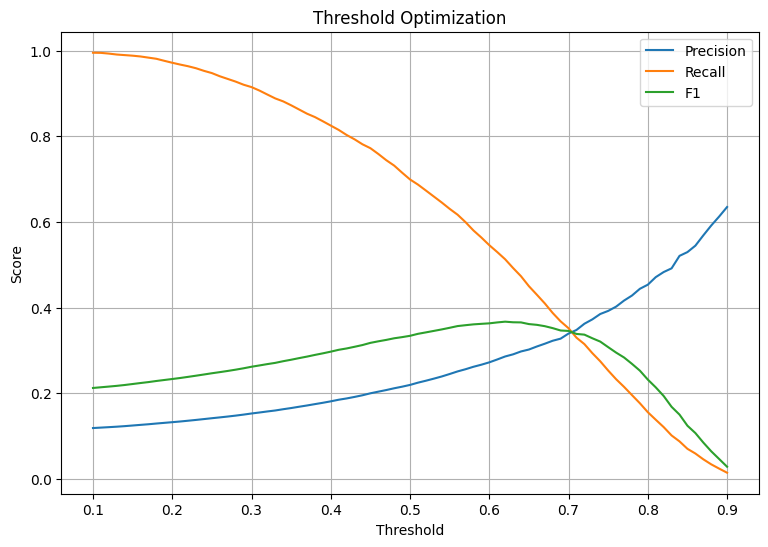

In [ ]:
plt.figure(figsize=(9,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold Optimization"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
optimal_threshold = best_threshold_row[
    "Threshold"
]

final_pred = (
    best_prob >= optimal_threshold
).astype(int)

print("=" * 50)
print("OPTIMIZED FINAL RESULTS")
print("=" * 50)

print(
    "Threshold :",
    round(optimal_threshold, 2)
)

print(
    "Accuracy  :",
    round(
        accuracy_score(
            y_test,
            final_pred
        ),
        4
    )
)

print(
    "Precision :",
    round(
        precision_score(
            y_test,
            final_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall    :",
    round(
        recall_score(
            y_test,
            final_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score  :",
    round(
        f1_score(
            y_test,
            final_pred,
            zero_division=0
        ),
        4
    )
)

OPTIMIZED FINAL RESULTS
Threshold : 0.62
Accuracy  : 0.7948
Precision : 0.2861
Recall    : 0.5131
F1 Score  : 0.3673
